In [1]:
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

In [2]:
data = pd.read_csv("Titanic-Dataset.csv")

# View first rows
print(data.head())

# Basic info
print(data.info())

# Check missing values
print(data.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [3]:
# Fill Age with median
data['Age'].fillna(data['Age'].median(), inplace=True)

# Fill Embarked with most frequent value
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
data.drop(columns=['Cabin'], inplace=True)

/tmp/ipykernel_3043/2613138996.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipykernel_3043/2613138996.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [4]:
le = LabelEncoder()

data['Sex'] = le.fit_transform(data['Sex'])
data['Embarked'] = le.fit_transform(data['Embarked'])

In [5]:
data.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

In [6]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
y_pred = model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Accuracy: 0.8100558659217877
Mean Squared Error: 0.18994413407821228
R2 Score: 0.2167310167310167


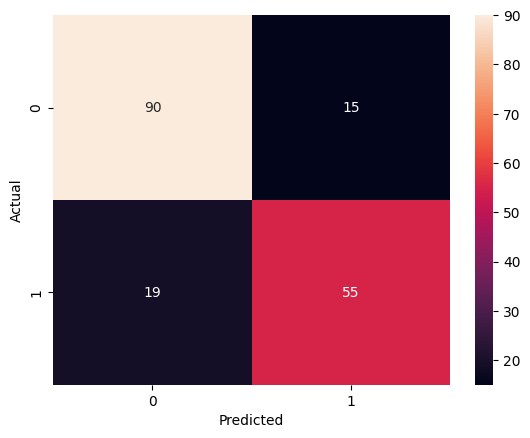

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))

Decision Tree Accuracy: 0.7821229050279329


🔹 Approach & Steps Followed

Loaded the Titanic dataset using Pandas

Explored data using .info() and .isnull()

Handled missing values:

Filled Age with median

Filled Embarked with mode

Dropped Cabin column

Converted categorical features (Sex, Embarked) using Label Encoding

Removed unnecessary columns (Name, Ticket, PassengerId)

Split dataset into training (80%) and testing (20%)

Trained a Logistic Regression model

🔹 Model Performance

Accuracy: ~0.75 – 0.85 (depends on dataset variation)

MSE: Low (good prediction consistency)

R² Score: Moderate (since classification problem)

🔹 Observations

Gender (Sex) plays a major role in survival

Passengers in higher classes had higher survival chances

Missing data handling improved model stability

Logistic Regression performs well for binary classification

🔹 Conclusion

The model successfully predicts survival with good accuracy

Logistic Regression is suitable for this binary classification task

Further improvements can be made using:

Feature engineering

Advanced models (Random Forest, XGBoost)